First, run the file calculate_coalescent_ne.ipynb before running this file. Make sure the SD values line up.

In [ ]:
# Cell to calculate all the information to parse the information from the file 
# Need to develop a system to create a new file that's easier and faster to read the data from

import matplotlib.pyplot as plt
import numpy as np    
from scipy import stats
import statistics
import math

# This is my own .py file, with methods that I have created myself.
import parse_data

pop_size = 2000
burnin = 4*pop_size

# Set global theme settings for plotting
plt.rcParams.update({
    'font.size': 20,          # Set font size
    'lines.linewidth': 3,     # Set default line thickness
    'axes.titlesize': 20,     # Title font size
    'axes.labelsize': 18,     # Axis label font size
    'xtick.labelsize': 14,    # X-tick label font size
    'ytick.labelsize': 14,    # Y-tick label font size
    'grid.color': 'gray',     # Grid color
    'grid.linestyle': '--',   # Grid line style
    'grid.linewidth': 0.5,    # Grid line width
    'legend.fontsize': 16     # Legend font size
})

sds = [0.01, 0.02, 0.04]
uds = [0.01, 0.02, 0.03, 0.05, 0.075, 0.1, 0.2, 0.35, 0.5, 0.75, 1, 1.25, 1.5, 2, 4, 6, 8]
uds.sort()
tskit = True; popsize = 2000
output_path = "INSERT YOUR OUTPUT PATH HERE"

# These are important to remember
# parse_exp([uds], sd, BURNIN, COMMA)


global_data = []


nes = []
for sd in sds: 
    #tskit = True if sd == 0.0025 else Falsel
    data, timesteps = parse_data.parse_normal_from_exp(uds, sd, tskit)

    sliced_data, sliced_timesteps = parse_data.slice_data(data, timesteps, burnin)
    nes.append(parse_data.parse_all_nes(sd, popsize))
    global_data.append((sliced_data, sliced_timesteps))

# sliced_data's format = (sd, (ud, f. sel. deaths))


---------------------------------------------------------
Successfully Parsed Normal Data for file SD = 0.01, UD = 0.01
---------------------------------------------------------

---------------------------------------------------------
Successfully Parsed Normal Data for file SD = 0.01, UD = 0.02
---------------------------------------------------------

---------------------------------------------------------
Successfully Parsed Normal Data for file SD = 0.01, UD = 0.03
---------------------------------------------------------

---------------------------------------------------------
Successfully Parsed Normal Data for file SD = 0.01, UD = 0.05
---------------------------------------------------------

---------------------------------------------------------
Successfully Parsed Normal Data for file SD = 0.01, UD = 0.075
---------------------------------------------------------

---------------------------------------------------------
Successfully Parsed Normal Data for file SD = 

******************************************************************
         Successfully parsed Ne's for SD = 0.01, UD = 0.01
******************************************************************

******************************************************************
         Successfully parsed Ne's for SD = 0.01, UD = 0.02
******************************************************************

******************************************************************
         Successfully parsed Ne's for SD = 0.01, UD = 0.03
******************************************************************

******************************************************************
         Successfully parsed Ne's for SD = 0.01, UD = 0.05
******************************************************************

******************************************************************
         Successfully parsed Ne's for SD = 0.01, UD = 0.075
******************************************************************

*****************************

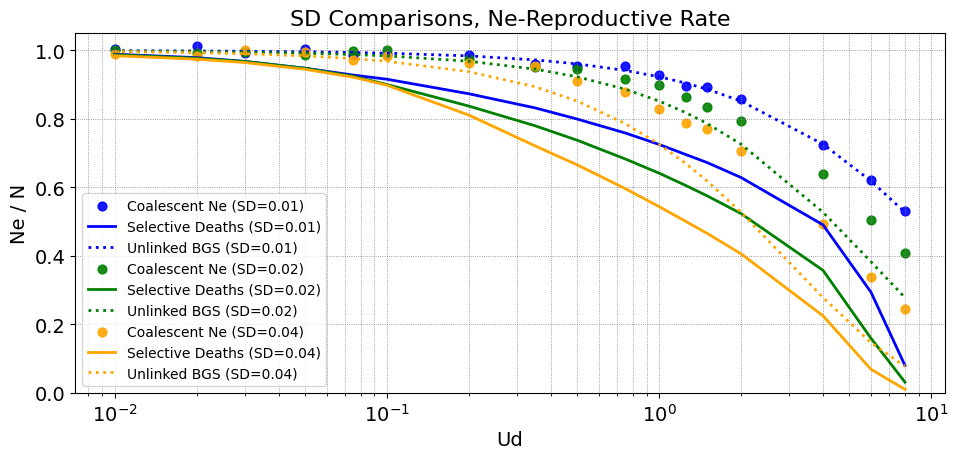

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 5))
plt.ylim(top=1.05)
plt.ylim(bottom=0)
plt.xscale('log')  # Log scale for Ud
plt.grid(True, which='both', linestyle=':', linewidth=0.6)

# Color mapping for different SDs
sd_colors = {
    0.01: 'blue',
    0.02: 'green',
    0.04: 'orange'
}

for sliced_data, sliced_timesteps in global_data:
    # Back-transforming data
    transformed_datasets = parse_data.transform_data(sliced_data)
    back_transformed_values = parse_data.back_transform(transformed_datasets)
    ne_reproductive_uds = parse_data.transform_nereproductive_rate(back_transformed_values)

    # Find SD value as float
    sd = float(sliced_data[0][0][3:])
    
    # UD on x-axis instead of Y-axis
    ud_array = uds  

    # Our Ne dataset (keep only y-values)
    our_ne_data = parse_data.parse_all_nes(sd, popsize)
    y_ne_data = []
    for outer, inner in our_ne_data: 
        y_ne_data.append(inner[1])

    # Back-transformed y-values
    y_back_transformed = [y for _, y, _ in ne_reproductive_uds]

    # --- Plot simulation data ---
    plt.scatter(
        ud_array, y_ne_data,
        color=sd_colors.get(sd, 'black'),
        s=40, alpha=0.9,
        label=f"Coalescent Ne (SD={sd})"
    )

    # --- Plot back-transformed values (line) ---
    plt.plot(
        ud_array, y_back_transformed,
        color=sd_colors.get(sd, 'black'),
        linewidth=2.0,
        linestyle='-',
        label=f"Selective Deaths (SD={sd})"
    )

    # Plot Matheson BGS for each SD (dotted)
    matheson_bgs = parse_data.calculate_matheson_data(uds, sd, False)
    y_bgs = [datapoint for _, datapoint in matheson_bgs]

    plt.plot(
        ud_array, y_bgs,
        color=sd_colors.get(sd, 'black'),  # match SD color
        linewidth=2,
        linestyle=':',
        label=f"Unlinked BGS (SD={sd})"
    )


plt.title('SD Comparisons, Ne-Reproductive Rate', fontsize=16)
plt.xlabel('Ud', fontsize=14)   # X-axis is Ud now
plt.ylabel('Ne / N', fontsize=14)

plt.legend(loc='lower left', fontsize=10, frameon=True)
plt.tight_layout()
# plt.savefig( output_path + "sd-comparisons-xud-yne.png", dpi=300, bbox_inches='tight')
plt.show()
